In [2]:
import numpy as np 

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import pandas as pd

from scipy import stats
from scipy.stats import mode
from scipy.special import gamma
r = np.random
r.seed(1)
from scipy.optimize import minimize
from iminuit import Minuit, cost
from scipy.integrate import quad
from numba import njit

from sklearn.neighbors import KernelDensity
import sklearn
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

## Notebook for problem set 3
Author: Aske Roelshøj (KVF851)

Date: 11/03 2026

## Problem 1a

In [3]:
ear_pot_trte = pd.read_csv('earning_potential_train_test_AMAS_2026.txt', delimiter = ',')
# Separate by class
high_ear = ear_pot_trte[ear_pot_trte['earning'] == ' >50K']
low_ear = ear_pot_trte[ear_pot_trte['earning'] != ' >50K']

# Sample 500 from each for test
high_test = high_ear.sample(n=500)
low_test = low_ear.sample(n=500)

#Remove the samples from the training set:
ear_pot_te = pd.concat([high_test, low_test]).sample(frac=1)  # shuffle
ear_pot_tr = ear_pot_trte.drop(ear_pot_te.index)
ear_pot_trte

,ID,age,education,gender,hours-per-week,earning
0,0,39,13,0,40,<=50K
1,1,50,13,0,13,<=50K
2,2,38,9,0,40,<=50K
3,3,53,7,0,40,<=50K
4,4,28,13,1,40,<=50K
...,...,...,...,...,...,...
4795,4795,34,13,0,40,<=50K
4796,4796,29,11,1,40,<=50K
4797,4797,46,13,0,50,>50K
4798,4798,36,9,0,40,<=50K


In [4]:
#Train the model. First separate w.r.t. earning: 
X_train = ear_pot_tr[['age', 'education', 'gender', 'hours-per-week']]
y_train = (ear_pot_tr['earning'] == ' >50K').astype(int)

X_test = ear_pot_te[['age', 'education', 'gender', 'hours-per-week']]
y_test = (ear_pot_te['earning'] == ' >50K').astype(int)

In [5]:
print(f"Test: <=50K: {(y_test == 0).sum()}, >50K: {(y_test == 1).sum()}")

Test: <=50K: 500, >50K: 500


In [6]:
bdt = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=300,
    learning_rate=0.5
)

bdt.fit(X_train, y_train)

bdt_score_train = bdt.decision_function(X_train)
bdt_score_test = bdt.decision_function(X_test)

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = bdt.predict(X_test)
acc = accuracy_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"Accuracy: (TP+TN)/(P+N) = ({tp}+{tn})/({(y_test==1).sum()}+{(y_test==0).sum()}) = {acc:.4f}")

Accuracy: (TP+TN)/(P+N) = (172+472)/(500+500) = 0.6440


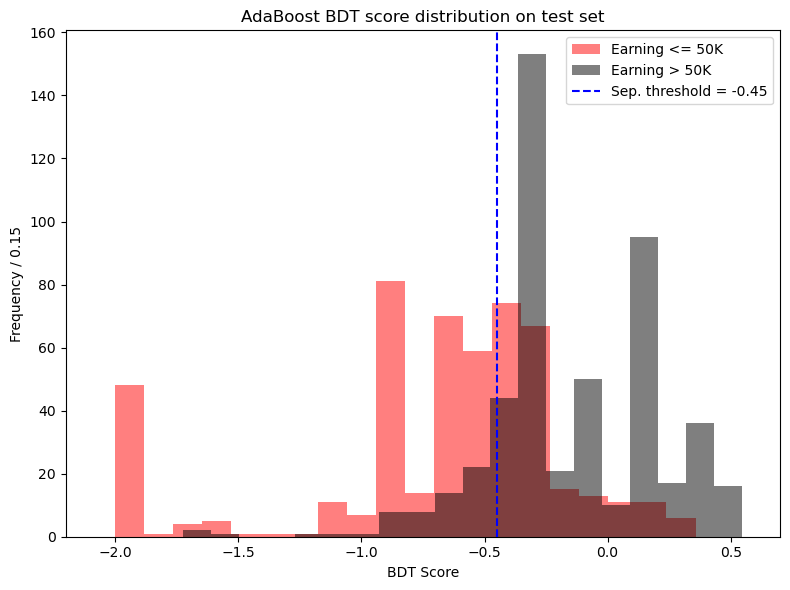

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(bdt_score_test[y_test == 0], bins=20, histtype='stepfilled', alpha=0.5, color='r', label='Earning <= 50K')
ax.hist(bdt_score_test[y_test == 1], bins=20, histtype='stepfilled', alpha = 0.5, color='k', label='Earning > 50K')
ax.set_xlabel('BDT Score')
bw = (0.7+2.2) / 20
ax.set_ylabel(f'Frequency / {bw:.2f}')
ax.set_title('AdaBoost BDT score distribution on test set')
ax.axvline(-0.45, color='b', linestyle='--', label='Sep. threshold = -0.45')
ax.set_xlim(-2.2,0.7)
ax.legend()
plt.tight_layout()
plt.show()

## Problem 1b

In [9]:
#Find the fraction of high and low earningers in the training set: 
high_ear_train_frac = ((y_train == 1).sum())/len(y_train)
low_ear_train_frac = (y_train == 0).sum()/len(y_train)
print(f"Training set: <=50K: {(y_train == 0).sum()}, >50K: {(y_train == 1).sum()}")
print(f"Fractions in training set: <=50K: {low_ear_train_frac:.4f}, >50K: {high_ear_train_frac:.4f}")

Training set: <=50K: 3139, >50K: 661
Fractions in training set: <=50K: 0.8261, >50K: 0.1739


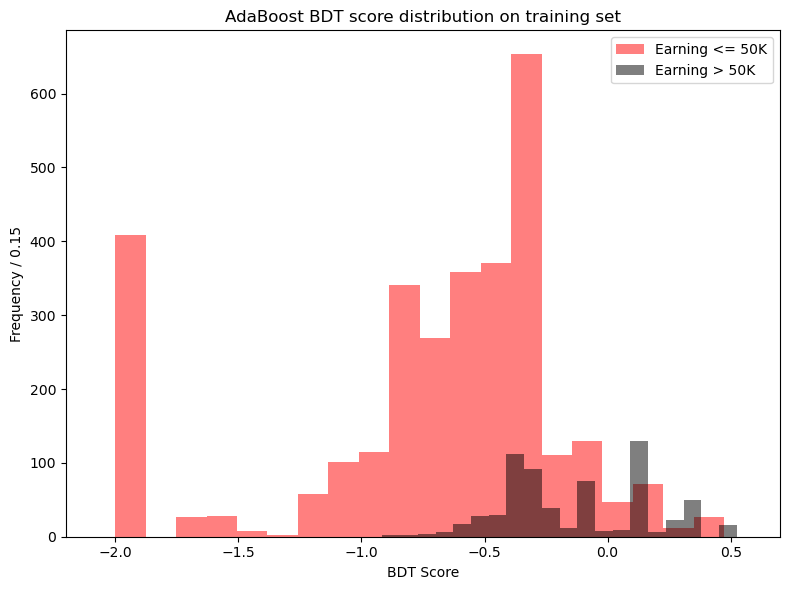

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(bdt_score_train[y_train == 0], bins=20, histtype='stepfilled', alpha=0.5, color='r', label='Earning <= 50K')
ax.hist(bdt_score_train[y_train == 1], bins=20, histtype='stepfilled', alpha = 0.5, color='k', label='Earning > 50K')
ax.set_xlabel('BDT Score')
bw = (0.7+2.2) / 20
ax.set_ylabel(f'Frequency / {bw:.2f}')
ax.set_title('AdaBoost BDT score distribution on training set')
ax.set_xlim(-2.2,0.7)
ax.legend()
plt.tight_layout()
plt.show()

## Problem 1c

In [11]:
ear_pot_real = pd.read_csv('earning_potential_real_2026.txt', delimiter = ',')
ear_pot_real

,ID,age,education,gender,hours-per-week
0,0,39,9,1,40
1,1,23,9,0,40
2,2,30,13,0,35
3,3,30,13,1,40
4,4,20,10,0,40
...,...,...,...,...,...
6507,6507,40,10,0,60
6508,6508,49,14,0,45
6509,6509,31,6,0,40
6510,6510,42,10,1,30


In [12]:
#run the classifier on ear_pot_real: 
X_real = ear_pot_real[['age', 'education', 'gender', 'hours-per-week']]
threshold = -0.45 # adjust this

y_real_pred = (bdt.decision_function(X_real) > threshold).astype(int)
ear_pot_real['predicted_earning'] = np.where(y_real_pred == 1, '>50K', '<=50K')

# Separate
real_high = ear_pot_real[ear_pot_real['predicted_earning'] == '>50K']
real_low = ear_pot_real[ear_pot_real['predicted_earning'] == '<=50K']

print(f"Predicted >50K: {len(real_high)}, <=50K: {len(real_low)}")

#Find the ids for the predicted high earners:
high_earner_ids = ear_pot_real.loc[y_real_pred == 1, 'ID'].values
low_earner_ids = ear_pot_real.loc[y_real_pred == 0, 'ID'].values

#Save in a txt file:
np.savetxt('aske.high_ID.txt', high_earner_ids, fmt='%d')
np.savetxt('aske.low_ID.txt', low_earner_ids, fmt='%d')

Predicted >50K: 3437, <=50K: 3075


## Problem 2a

In [13]:
#Retrive data and extract latitudes and longitudes
cpd_crash_data = pd.read_csv('cpd-crash-incidents.csv', delimiter=';')
cpd_crash_df = pd.DataFrame(cpd_crash_data)
latitudes = cpd_crash_data['lat'].fillna(cpd_crash_data['lat2'])
longitudes = cpd_crash_data['lon'].fillna(cpd_crash_data['lon2'])

In [14]:
long_mask = (longitudes >= -78.93) & (longitudes <= -78.72)
lat_mask = (latitudes >= 35.66) & (latitudes <= 35.88)
clean_long = longitudes[long_mask]
clean_lat = latitudes[lat_mask]
#Only take common indices:
common_indices = clean_long.index.intersection(clean_lat.index)
clean_long = clean_long.loc[common_indices]
clean_lat = clean_lat.loc[common_indices]
print(f"Number of crash incidents after cleaning: {len(clean_long)}")

Number of crash incidents after cleaning: 22267


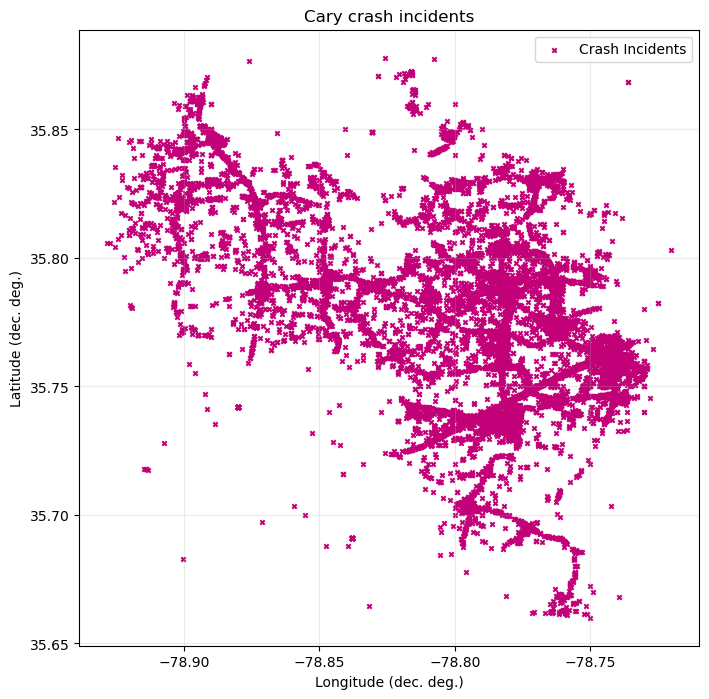

In [15]:
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(clean_long, clean_lat, color = 'xkcd:magenta', marker = 'x', s=10, label = 'Crash Incidents')
ax.set_title('Cary crash incidents')
ax.set_xlabel('Longitude (dec. deg.)')
ax.set_ylabel('Latitude (dec. deg.)')
#Limits based on google maps of Cary.
ax.grid(alpha = 0.25)
ax.legend(loc = 'upper right')
plt.show()


In [16]:
#Let us convert the time data: 
times = cpd_crash_data['ta_time']
times = pd.to_datetime(times, format='mixed').dt.time
times = times.apply(lambda x: x.hour + x.minute/60 + x.second/3600)
times

0        13.335833
1        10.633333
2        14.358889
3        16.722500
4         9.005556
           ...    
23453    21.012500
23454    20.302500
23455    17.984444
23456    17.899167
23457    20.752500
Name: ta_time, Length: 23458, dtype: float64

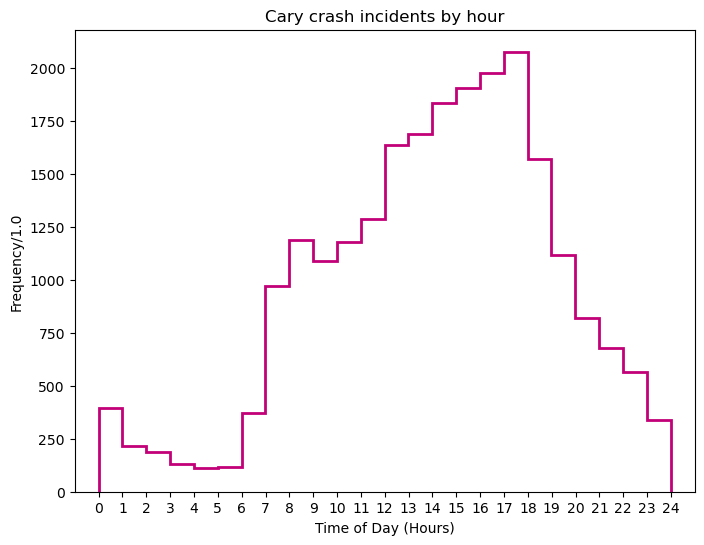

In [17]:
#Plot the data in a histogram: 
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(times, bins=24, histtype='step', alpha = 1, linewidth = 2, color = 'xkcd:magenta')
ax.set_title('Cary crash incidents by hour')
ax.set_xlabel('Time of Day (Hours)')
ax.set_ylabel(f'Frequency/{1.0}')
ax.set_xlim(-1, 25)
ax.set_xticks(np.arange(0, 25, 1))
plt.show()


## Problem 2b

In [18]:
@njit
def u(x, x_d, h):
    return (x - x_d) / h 

@njit
def epanechnikov(point, center,h):
    u_val = u(point, center, h)
    if abs(u_val) <= 1:
        return (3/4) * (1 - u_val**2)
    else:
        return 0

@njit
def kde_epanechnikov(x, data, h, period=24):
    probs = 0
    for x_d in data:
        diff = abs(x - x_d)
        u_val = diff / h
        if u_val <= 1:
            probs += (3/4) * (1 - u_val**2)
    probs /= (len(data) * h)
    return probs

times_tiled = np.concatenate([times-24,times, times + 24])  # Tile the data to handle circularity
x_times = np.linspace(0, 24, 10000)
kde_times = np.array([kde_epanechnikov(x, times_tiled, h=0.8) for x in x_times])
kde_scaled = kde_times * 3*len(times)

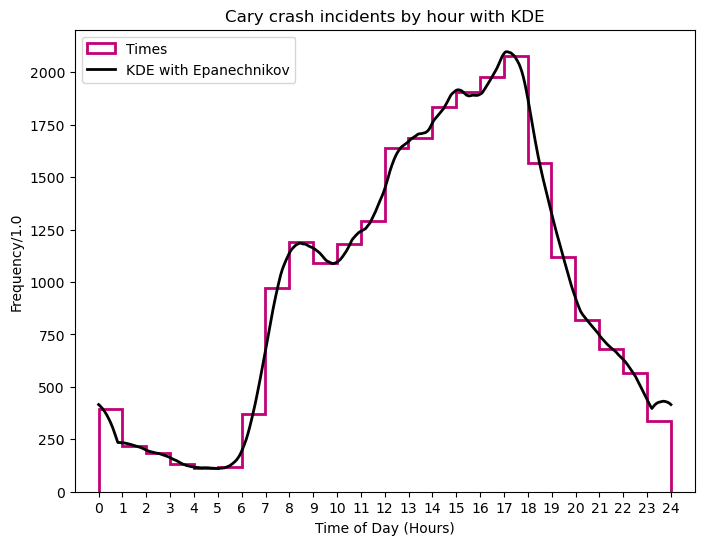

In [19]:
#Plot the PDF of the KDE:
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(times, bins=24, histtype='step', linewidth = 2, alpha = 1, color = 'xkcd:magenta', label = 'Times')
ax.plot(x_times, kde_scaled, color = 'k', linewidth = 2, label = 'KDE with Epanechnikov')
ax.set_title('Cary crash incidents by hour with KDE')
ax.set_xlabel('Time of Day (Hours)')
ax.set_ylabel(f'Frequency/{1.0}')
ax.set_xlim(-1, 25)
ax.set_xticks(np.arange(0, 25, 1))
ax.legend(  loc = 'upper left');

In [20]:
eval_times = np.array([0+23/60, 1+49/60, 8+12/60, 15+55/60, 18+2/60, 21+12/60, 23+44/60])
kde_eval_times = np.array([kde_epanechnikov(x, times.values, h=0.8) for x in eval_times])


df_eval = pd.DataFrame({
    'Time': ['00:23', '01:49', '08:12', '15:55', '18:02', '21:12', '23:44'],
    'Time (hours)': eval_times,
    'KDE value': kde_eval_times
})

print(df_eval.to_latex(index=False, float_format='%.4f', column_format='ccc', caption='KDE values at specified times'))

\begin{table}
\caption{KDE values at specified times}
\begin{tabular}{ccc}
\toprule
Time & Time (hours) & KDE value \\
\midrule
00:23 & 0.3833 & 0.0132 \\
01:49 & 1.8167 & 0.0089 \\
08:12 & 8.2000 & 0.0498 \\
15:55 & 15.9167 & 0.0806 \\
18:02 & 18.0333 & 0.0790 \\
21:12 & 21.2000 & 0.0307 \\
23:44 & 23.7333 & 0.0101 \\
\bottomrule
\end{tabular}
\end{table}



In [21]:
#Find what 2-hour interval to choose if patrolling decreases the probability of a crash by 10%:
dx = x_times[1] - x_times[0]
window_bins = int(2 / dx)  # number of bins in 2 hours
# Wrap the KDE for circular sliding window
kde_wrapped = np.concatenate([kde_times, kde_times[:window_bins]])
cumsum = np.cumsum(kde_wrapped) * dx
integrals = cumsum[window_bins:] - cumsum[:len(kde_times)]
best_idx = np.argmax(integrals)
best_t = x_times[best_idx]
print(f"Best 2h window: {best_t:.2f} to {(best_t+2)%24:.2f} hours")
#Reformat hours to HH:MM format:
def format_time(hour):
    h = int(hour)
    m = int((hour - h) * 60)
    return f"{h:02d}:{m:02d}"

print(f"Best 2h window: {format_time(best_t)} to {format_time((best_t+2)%24)}")

Best 2h window: 15.97 to 17.97 hours
Best 2h window: 15:57 to 17:57


In [22]:
#Find the the amount of crashes between best_t and best_t + 2 hours using only KDE:
start_time = best_t
end_time = (best_t + 2) % 24 
start_idx = int(start_time / dx)
end_idx = int(end_time / dx)
if end_idx < start_idx:  # Wrap around case
    twoh_crash = np.sum(kde_scaled[start_idx:])*dx + np.sum(kde_scaled[:end_idx])*dx
else:
    twoh_crash = np.sum(kde_scaled[start_idx:end_idx])*dx

print(f"Estimated crashes in best 2h window: {twoh_crash:.2f} reduced by 10% to: {twoh_crash * 0.9:.2f}")

Estimated crashes in best 2h window: 4022.05 reduced by 10% to: 3619.85


In [23]:
tot_crashes = np.sum(kde_scaled)*dx
tot_no2h = (tot_crashes-twoh_crash)
tot_red = tot_no2h + twoh_crash*0.9

print(f"Total crashes: {tot_crashes:.2f}")
print(f"Crashes outside 2h window: {tot_no2h:.2f}")
print(f"Crashes inside 2h window after 10% reduction: {twoh_crash*0.9:.2f}")
print(f"Total crashes after 10% reduction in 2h window: {tot_red:.2f}")

#Percentage reduction:
reduction_percentage = (tot_crashes - tot_red) / tot_crashes * 100
print(f"Percentage reduction in total crashes: {reduction_percentage:.2f}%")

Total crashes: 23459.00
Crashes outside 2h window: 19436.95
Crashes inside 2h window after 10% reduction: 3619.85
Total crashes after 10% reduction in 2h window: 23056.79
Percentage reduction in total crashes: 1.71%


## Problem 2c

In [24]:
#Now lets make a 2d KDE of the latitudes and longitudes:
@njit
def kde_2d_epanechnikov(x_grid, y_grid, data_x, data_y, hx, hy):
    nx = len(x_grid)
    ny = len(y_grid)
    result = np.zeros((ny, nx))
    n = len(data_x)
    for iy in range(ny):
        for ix in range(nx):
            density = 0.0
            for k in range(n):
                ux = (x_grid[ix] - data_x[k]) / hx
                uy = (y_grid[iy] - data_y[k]) / hy
                if abs(ux) <= 1 and abs(uy) <= 1:
                    density += (0.75) * (1 - ux**2) * (0.75) * (1 - uy**2)/(hx * hy)
            result[iy, ix] = density / (n)
    return result

x_grid = np.linspace(-78.93, -78.72, 500)
y_grid = np.linspace(35.66, 35.88, 500)

In [25]:
kde_2d = kde_2d_epanechnikov(x_grid, y_grid, clean_long.values, clean_lat.values, hx=0.01, hy=0.01)

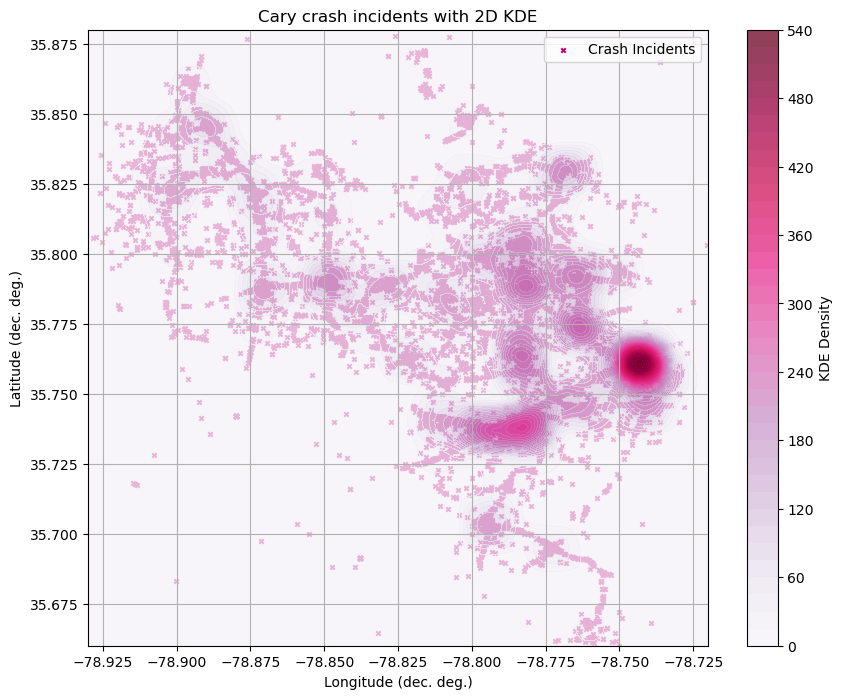

In [26]:
#Plotting the P:
fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(clean_long, clean_lat, color = 'xkcd:magenta', marker = 'x', s=10, label = 'Crash Incidents')
cf = ax.contourf(x_grid, y_grid, kde_2d, levels=50, cmap='PuRd', alpha=0.75)
fig.colorbar(cf, ax=ax, label='KDE Density')
ax.grid()
ax.set_title('Cary crash incidents with 2D KDE')
ax.set_xlabel('Longitude (dec. deg.)')
ax.set_ylabel('Latitude (dec. deg.)')
ax.legend(loc = 'upper right'); 

In [27]:
long_eval = np.array([-78.76, -78.72])
lat_eval = np.array([35.74, 35.78])
#Find the total percentage of crashes in the rectangle defined by long_eval and lat_eval using our KDE:
x_min_idx = np.searchsorted(x_grid, long_eval[0])
x_max_idx = np.searchsorted(x_grid, long_eval[1])
y_min_idx = np.searchsorted(y_grid, lat_eval[0])
y_max_idx = np.searchsorted(y_grid, lat_eval[1])

kde_sum = np.sum(kde_2d[y_min_idx:y_max_idx, x_min_idx:x_max_idx]) * (x_grid[1] - x_grid[0]) * (y_grid[1] - y_grid[0])
total_kde_sum = np.sum(kde_2d) * (x_grid[1] - x_grid[0]) * (y_grid[1] - y_grid[0])
percentage_in_rectangle = (kde_sum / total_kde_sum) * 100
print(f"Estimated percentage of crashes in rectangle: {percentage_in_rectangle:.2f}%")

Estimated percentage of crashes in rectangle: 18.62%


## Problem 3a

In [28]:
prod_shares = np.array([0.35, 0.15, 0.05, 0.20, 0.25])
defec_shares = np.array([0.02,0.04, 0.10, 0.035, 0.031])

In [29]:
#Let us Bayes to determine the probability that a defective pacemaker came from A2: 
prior_A2 = prod_shares[1]
likelihood_A2 = defec_shares[1]
p_d = np.sum(prod_shares * defec_shares)
print(p_d)
posterior_A2 = (likelihood_A2 * prior_A2) / p_d
print(f"Posterior probability that a defective pacemaker came from A2: {posterior_A2:.4f}")

0.03275
Posterior probability that a defective pacemaker came from A2: 0.1832


In [30]:
post_ai_s = np.zeros(len(prod_shares))
for i in range(len(prod_shares)):
    prior = prod_shares[i]
    likelihood = defec_shares[i]
    post_ai_s[i] = (likelihood * prior) / p_d

df_post = pd.DataFrame({
    'Facilities': [f'A{i+1}' for i in range(len(prod_shares))],
    'Prior': prod_shares,
    'Likelihood': defec_shares,
    'Posterior': post_ai_s
})

print(df_post.to_latex(index=False, float_format='%.4f', column_format='cccc', caption='Posterior probabilities for each facility'))
print(f"Max posterior: {max(post_ai_s):.4f}")

\begin{table}
\caption{Posterior probabilities for each facility}
\begin{tabular}{cccc}
\toprule
Facilities & Prior & Likelihood & Posterior \\
\midrule
A1 & 0.3500 & 0.0200 & 0.2137 \\
A2 & 0.1500 & 0.0400 & 0.1832 \\
A3 & 0.0500 & 0.1000 & 0.1527 \\
A4 & 0.2000 & 0.0350 & 0.2137 \\
A5 & 0.2500 & 0.0310 & 0.2366 \\
\bottomrule
\end{tabular}
\end{table}

Max posterior: 0.2366


## Problem 3b

In [31]:
const_needed = np.max(prod_shares*defec_shares)
new_defec_shares = const_needed / prod_shares

new_p_d = np.sum(prod_shares * new_defec_shares)
new_posteriors = (new_defec_shares * prod_shares) / new_p_d

df_3b = pd.DataFrame({
    'Facility': [f'A{i+1}' for i in range(len(prod_shares))],
    'Original $P(D|A_i)$': defec_shares,
    'New $P(D|A_i)$': new_defec_shares,
    'New Posterior': new_posteriors
})

print(df_3b.to_latex(index=False, float_format='%.4f', column_format='cccc',
                      caption='New defect rates for equal posteriors', escape=False))

\begin{table}
\caption{New defect rates for equal posteriors}
\begin{tabular}{cccc}
\toprule
Facility & Original $P(D|A_i)$ & New $P(D|A_i)$ & New Posterior \\
\midrule
A1 & 0.0200 & 0.0221 & 0.2000 \\
A2 & 0.0400 & 0.0517 & 0.2000 \\
A3 & 0.1000 & 0.1550 & 0.2000 \\
A4 & 0.0350 & 0.0387 & 0.2000 \\
A5 & 0.0310 & 0.0310 & 0.2000 \\
\bottomrule
\end{tabular}
\end{table}



## Problem 4a

In [32]:
re_land_data = pd.read_csv('Remodeler_Landscape.csv', delimiter = ',')
re_land_data

,Position,Potential
0,0.0,243.701389
1,0.5,256.145533
2,1.0,249.055005
3,1.5,262.782481
4,2.0,255.444088
...,...,...
95,47.5,254.335251
96,48.0,246.804414
97,48.5,256.495798
98,49.0,248.136814


In [33]:
land_pos = re_land_data['Position'].values
land_pot = re_land_data['Potential'].values
v_lookup =  dict(zip(land_pos, land_pot))

In [34]:
#define proposal function
def prop_func(x, beta):
    return np.exp(-v_lookup[x]*beta)

def r_val(x_p, x_old, beta):
    num = prop_func(x_p, beta)
    denom = prop_func(x_old, beta)
    return num / denom

In [74]:
def mcmc_mh(n_iterations, beta, pos):
    pos_int = pos[np.floor(pos) == pos]
    N = int(max(pos_int) + 1)
    samples = np.empty(n_iterations, dtype=float)
    x_now = np.random.choice(pos_int)  # Start at a random position from the integer positions

    residence_times = {p: [] for p in pos_int}
    current_stay = 0

    for i in range(n_iterations):

        if np.random.random() < 0.5:
            x_p = (x_now + 1) % N  
        else:
            x_p = (x_now - 1) % N 

        # Standard Metropolis-Hastings acceptance ratio
        r = r_val(x_p, x_now, beta)
        
        if r >= 1 or np.random.uniform() < r:
            residence_times[x_now].append(current_stay)
            x_now = x_p
            current_stay = 1
        else:
            current_stay += 1

        samples[i] = x_now

    residence_times[x_now].append(current_stay)
    return samples, residence_times

In [75]:
beta_vals = np.array([0.01, 0.1, 1])
convergence_iters = [1000, 100000, 1000000]  # increasing iterations to show convergence

In [76]:
#Determine the relative proabilites: 
rel_probs = []
for beta in beta_vals:
    rel_i_prob = np.zeros(int(len(land_pos)/2))
    for i in range(len(rel_i_prob)):
        rel_i_prob[i] = np.exp(-v_lookup[i] * beta)
    rel_probs.append(rel_i_prob)
rel_probs = np.array(rel_probs)
rel_probs /= rel_probs.sum(axis=1, keepdims=True) #Normalize. 

In [77]:
# Run one long MCMC chain per beta, then slice for convergence comparison
mcmc_samples = []
mcmc_residence = []  # store residence times per beta
max_iter = max(convergence_iters)
for beta in beta_vals:
    long_chain, res_times = mcmc_mh(max_iter, beta, land_pos)
    # Slice the same chain at increasing lengths
    beta_samples = [long_chain[:n] for n in convergence_iters]
    mcmc_samples.append(beta_samples)
    mcmc_residence.append(res_times)

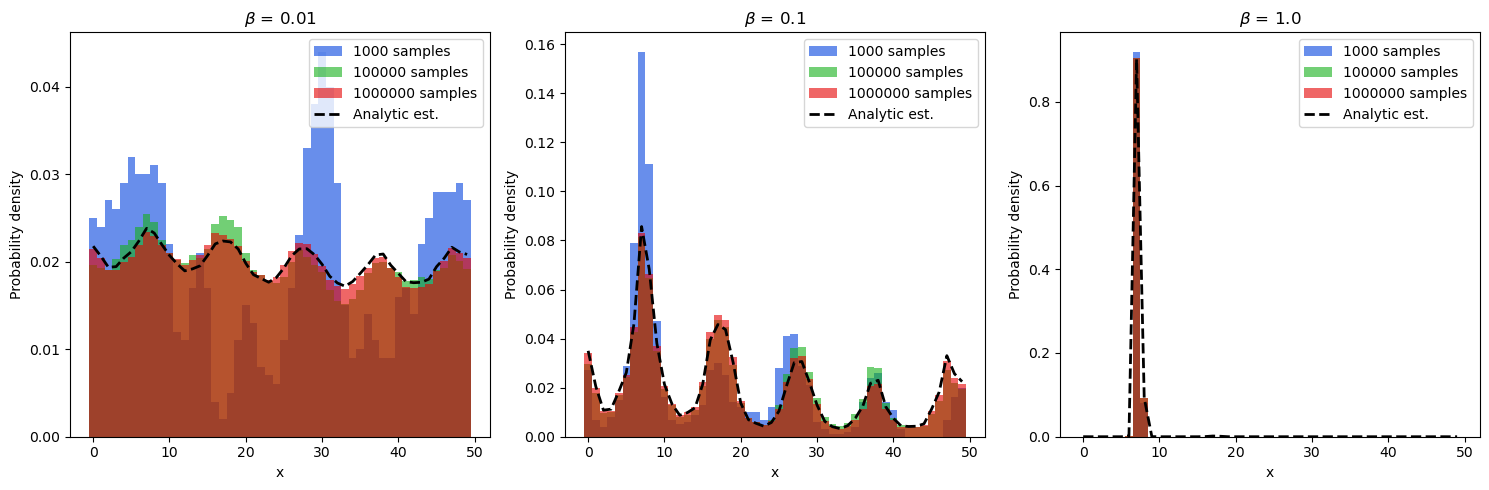

In [78]:
# Convergence plot:
pos_int = land_pos[np.floor(land_pos) == land_pos]
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
colors = ['xkcd:blue', 'xkcd:green', 'xkcd:red']

for i, beta in enumerate(beta_vals):
    for j in range(len(convergence_iters)):
        # Count visits to each integer position and normalize
        counts = np.array([np.sum(mcmc_samples[i][j] == p) for p in pos_int])
        counts = counts / counts.sum()
        ax[i].hist(mcmc_samples[i][j], bins=np.arange(-0.5, max(pos_int)+1.5, 1), density=True, alpha=0.6, color=colors[j], label=f'{convergence_iters[j]} samples')
    ax[i].plot(pos_int, rel_probs[i], 'k--', linewidth=2, label='Analytic est.')
    ax[i].set_title(fr'$\beta$ = {beta}')
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('Probability density')
    ax[i].legend(loc='upper right')
plt.tight_layout()
plt.show()

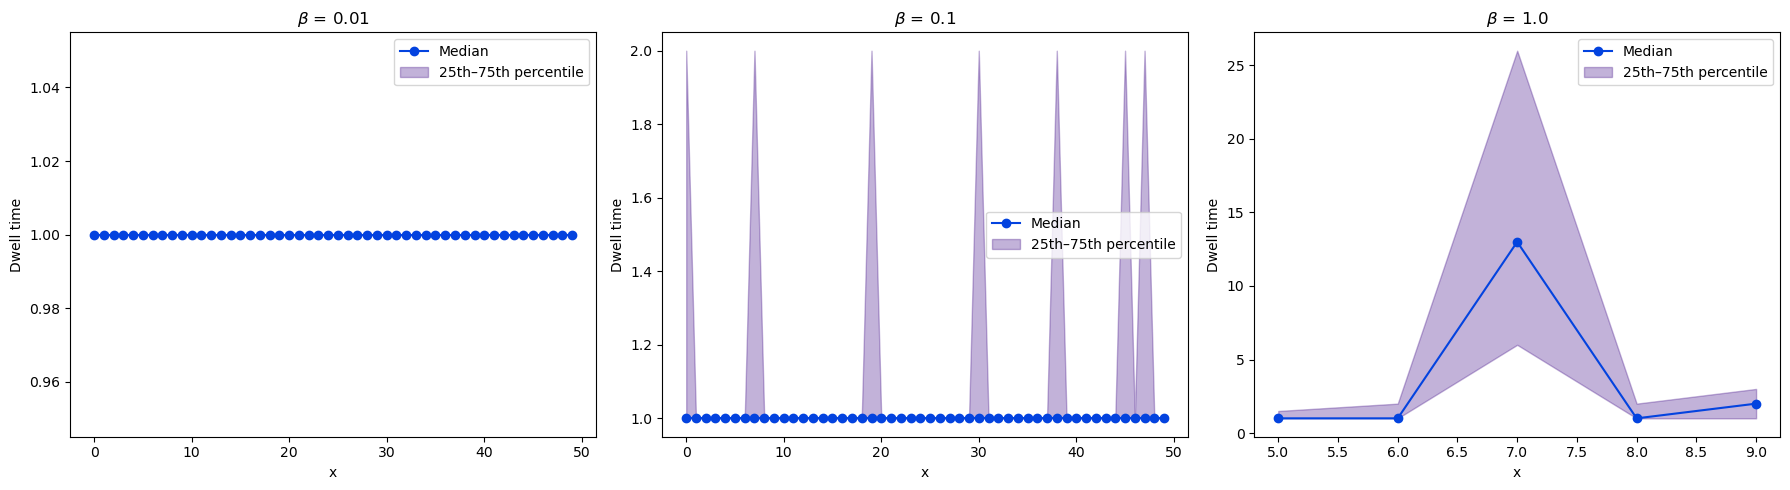

In [101]:
# Dwell time (residence time) distribution per position
pos_int = land_pos[np.floor(land_pos) == land_pos]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, beta in enumerate(beta_vals):
    res = mcmc_residence[i]

    visited_pos = []
    med_vals = []
    q25_vals = []
    q75_vals = []

    for p in sorted(pos_int):
        dts = res[p]
        if len(dts) == 0:
            continue
        visited_pos.append(int(p))
        med_vals.append(np.median(dts))
        q25_vals.append(np.percentile(dts, 25))
        q75_vals.append(np.percentile(dts, 75))

    med_vals = np.array(med_vals)
    q25_vals = np.array(q25_vals)
    q75_vals = np.array(q75_vals)

    axes[i].plot(visited_pos, med_vals, 'o-', color='xkcd:blue', label='Median')
    axes[i].fill_between(visited_pos, q25_vals, q75_vals, alpha=0.3, color='xkcd:indigo', label='25th–75th percentile')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('Dwell time')
    axes[i].set_title(fr'$\beta$ = {beta}')
    axes[i].legend()
plt.tight_layout()
plt.show()

## Problem 4b

In [117]:
#mcmc with remodeller:
def metropolis_with_remodeller(n_iterations, beta, pos, tau=1/25, bias=None):
    #bias = 1 means right, bias = 0 means left, bias = None means no bias.
    pos_int = pos[np.floor(pos) == pos]
    N = int(max(pos_int) + 1)
    samples = np.empty(n_iterations, dtype=float)
    x_now = np.random.choice(pos_int)
    
    remodeller_attached = False
    direction = None
    
    for i in range(n_iterations):
        # Remodeller state switching
        if remodeller_attached:
            if np.random.uniform() < tau:
                remodeller_attached = False
                direction = None
        else:
            if np.random.uniform() < tau:
                remodeller_attached = True
                # When attaching, choose direction with bias if given
                if bias is None:
                    direction = np.random.choice([-1, 1])
                else:
                    direction = 1 if np.random.uniform() < bias else -1
        
        # Propose move
        if remodeller_attached:
            x_p = (x_now + direction) % N
        else:
            # Propose with bias if given
            if bias is None:
                move = np.random.choice([-1, 1])
            else:
                move = 1 if np.random.uniform() < bias else -1
            x_p = (x_now + move) % N
        
        # MH acceptance
        r = r_val(x_p, x_now, beta)
        if r >= 1 or np.random.uniform() < r:
            x_now = x_p
        samples[i] = x_now
    return samples

beta = 0.25
remodeller_tau = 0.04  # 1/25 steps


In [118]:
#Calculate analytic distribution for beta = 0.25:
rel_i_prob = np.zeros(int(len(land_pos)/2))
for i in range(len(rel_i_prob)):
    rel_i_prob[i] = np.exp(-v_lookup[i] * beta)
rel_i_prob /= rel_i_prob.sum() #Normalize.


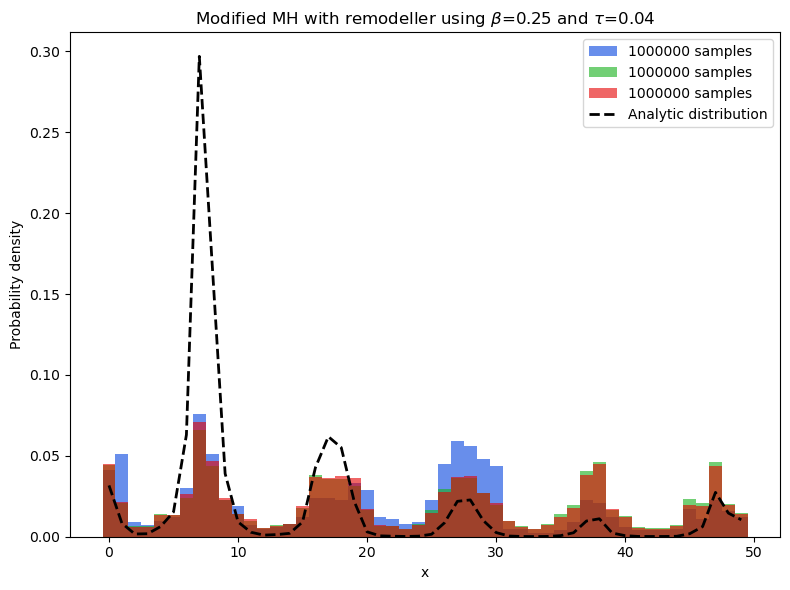

In [119]:
# Plot distribution as a histogram and compare to analytic:
pos_int = land_pos[np.floor(land_pos) == land_pos]
fig, ax = plt.subplots(figsize=(8,6))

#plot for all convergence iterations
for i, n_iter in enumerate(convergence_iters):
    samples_remodeller = metropolis_with_remodeller(n_iter, beta, land_pos, tau=remodeller_tau)
    ax.hist(samples_remodeller, bins=np.arange(-0.5, max(pos_int)+1.5, 1), density=True, alpha=0.6, color=colors[i], label=f'{convergence_iters[j]} samples')
ax.plot(pos_int, rel_i_prob, 'k--', linewidth=2, label='Analytic distribution')
ax.set_xlabel('x')
ax.set_ylabel('Probability density')
ax.set_title(f'Modified MH with remodeller using $\\beta$={beta} and $\\tau$={remodeller_tau}')
ax.legend()
plt.tight_layout()
plt.show()

In [1]:
#Let do for different taus:
taus = [0.01, 0.04, 0.1]  #

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for i, tau in enumerate(taus):
    samples_remodeller = metropolis_with_remodeller(max_iter, beta, land_pos, tau=tau)
    ax[i].hist(samples_remodeller, bins=np.arange(-0.5, max(pos_int)+1.5, 1), density=True, alpha=0.6, color='xkcd:red', label=f'$\\tau$={tau}')
    ax[i].plot(pos_int, rel_i_prob, 'k--', linewidth=2, label='Analytic distribution')
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('Probability density')
    ax[i].set_title(f'Modified MH with remodeller using $\\beta$={beta} and $\\tau$={tau}')
    ax[i].legend()
plt.tight_layout()

NameError: name 'plt' is not defined

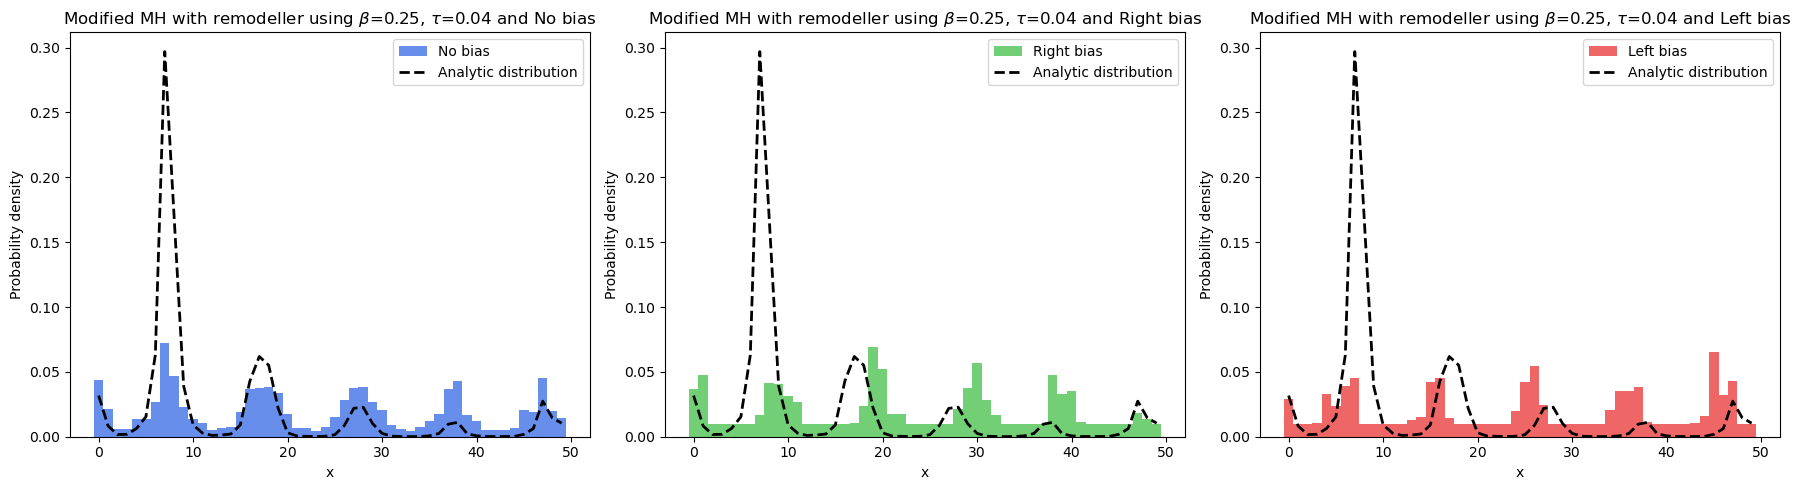

In [123]:
#Let us plot with no bias, with a left and with a right bias:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
biases = [None, 1, 0]  
bias_labels = ['No bias', 'Right bias', 'Left bias']
for i, bias in enumerate(biases):
    samples_remodeller = metropolis_with_remodeller(max_iter, beta, land_pos, tau=remodeller_tau, bias=bias)
    ax[i].hist(samples_remodeller, bins=np.arange(-0.5, max(pos_int)+1.5, 1), density=True, alpha=0.6, color=colors[i], label=bias_labels[i])
    ax[i].plot(pos_int, rel_i_prob, 'k--', linewidth=2, label='Analytic distribution')
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('Probability density')
    ax[i].set_title(f'Modified MH with remodeller using $\\beta$={beta}, $\\tau$={remodeller_tau} and {bias_labels[i]}')
    ax[i].legend()
plt.tight_layout()
plt.show()